# Create Sub-sampled SfM Models
This script will sample an existing SfM model into 2 "sub-models" that we can use for training

In [2]:
from pycolmap import Reconstruction
%load_ext autoreload
%autoreload 2

import pycolmap
import pathlib

model_path = pathlib.Path('./output/01_nerf/02_lego_large/1762043798762/0')

# Load the reconstruction
reconstruction = pycolmap.Reconstruction(model_path)

# Print basic info about the reconstruction
print(f"Number of registered images: {len(reconstruction.images)}")
print(f"Number of 3D points: {len(reconstruction.points3D)}")

Number of registered images: 69
Number of 3D points: 6672


## Sanity Check: Visualize the models

Filtered outliers: kept 6644, dropped 28.


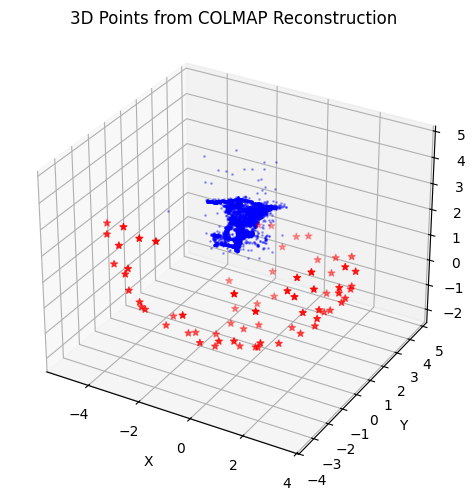

In [3]:
import utils

utils.colmap_3d_points(reconstruction, filter_outliers=True, show_cameras=True)

In [4]:
utils.colmap_3d_points_interactive(reconstruction, filter_outliers=True, show_cameras=True)

Filtered outliers: kept 6644, dropped 28.


## Draft teams

Here we will create a subset by "drafting" images to each subset, one at a time. At each step, we will take the image that is closest to the "team captain" image.

In [3]:
import random
import utils

# Create a set for all images indexes that we can draft from
draft_pool = set(reconstruction.images.keys())

# Sample (without replacement!) the two team captains
captain_a_id, captain_b_id = random.sample(list(draft_pool), 2)
print(f"Captain A: {captain_a_id}\nCaptain B: {captain_b_id}")

# Remove our captains from the pool
draft_pool.remove(captain_a_id)
draft_pool.remove(captain_b_id)

# Create the sets that will hold our teams. Start off by adding the team captains
team_a: set = {captain_a_id}
team_b: set = {captain_b_id}

# To start easy, let's just do a random drafting strategy. We might improve this later by doing something like
# drafting nearest neighbors.
covisible_captain_a = set(utils.get_covisible_image_ids(reconstruction, captain_a_id))
covisible_captain_b = set(utils.get_covisible_image_ids(reconstruction, captain_b_id))

Captain A: 33
Captain B: 57


In [165]:
# TODO improve this algorithm! Right now, we can sometimes be left with images that are not added to any team. This is
# because neither team captain can see them. We need to do something more sophisticated, like build a minimum spanning tree kinda thing

# Iterate until teams cannot draft anymore
team_a_valid_draft_choices = covisible_captain_a & draft_pool
team_b_valid_draft_choices = covisible_captain_b & draft_pool
while team_a_valid_draft_choices or team_b_valid_draft_choices:
    # Make sure there are still elements covisible to captain A. Otherwise, we are done drafting for team A
    team_a_valid_draft_choices = covisible_captain_a & draft_pool
    if team_a_valid_draft_choices:
        # For now, we will just select a random covisible image. In the future, we can get fancy with nearest neighbor strategies
        draft_choice = random.sample(list(team_a_valid_draft_choices), 1)[0]
        draft_pool.remove(draft_choice)
        team_a.add(draft_choice)

    # Make sure there are still elements covisible to captain B. Otherwise, we are done drafting for team B
    team_b_valid_draft_choices = covisible_captain_b & draft_pool
    if team_b_valid_draft_choices:
        draft_choice = random.sample(list(team_b_valid_draft_choices), 1)[0]
        draft_pool.remove(draft_choice)
        team_b.add(draft_choice)

# Sanity check: our teams should not have any shared members!
assert team_a.isdisjoint(team_b)

In [5]:
utils.sample_image_subsets(reconstruction)

Captain A: 20
Captain B: 35


([1,
  5,
  6,
  7,
  8,
  9,
  12,
  13,
  14,
  15,
  16,
  19,
  20,
  24,
  25,
  26,
  28,
  29,
  30,
  31,
  33,
  34,
  37,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  48,
  50,
  51,
  52,
  53,
  54,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  66,
  67],
 [32, 35, 68, 69, 3, 11, 47, 49, 18, 17, 55, 22, 23, 56, 27])